# Lab 1 — Single-Node Perceptron

A single sigmoid node (no hidden layer) trained with online gradient descent on two logic gates:

- **AND** — linearly separable, so the perceptron learns it.
- **XOR** — not linearly separable, so the same perceptron cannot learn it.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np

from numpy_nn import ACTIVATIONS, COSTS, Layer, Network, random_weights, zero_bias
from numpy_trainer import DataLoader, Trainer, plot_decision_boundary, plot_history, print_predictions

LEARNING_RATE = 0.7
EPOCHS = 500

GATE_INPUTS = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
AND_TARGETS = np.array([[0], [0], [0], [1]], dtype=float)
XOR_TARGETS = np.array([[0], [1], [1], [0]], dtype=float)


def build_perceptron() -> Network:
    return Network(
        Layer.build(
            input_size=2, output_size=1,
            weight=random_weights(input_size=2, output_size=1), bias=zero_bias(1),
            activation=ACTIVATIONS.SIGMOID,
        )
    )


def train_gate(network, targets):
    # one sample per update, always in the same order: plain online gradient descent
    trainer = Trainer(network, cost=COSTS.MSE, learning_rate=LEARNING_RATE)
    loader = DataLoader(GATE_INPUTS, targets, batch_size=1, shuffle=False)
    trainer.train(loader, epochs=EPOCHS, print_interval=100)
    return trainer

def report(network, inputs, targets):
    for index, layer in enumerate(network.layers):
        print(f"layer {index} weights: {np.round(layer.weights, 4).tolist()}")
        print(f"layer {index} bias:    {np.round(layer.bias, 4).tolist()}")
    print()
    print_predictions(inputs, targets, network.forward(inputs))

## AND gate

AND is linearly separable — a single node can draw one line that puts `(1, 1)` on
one side and the other three points on the other.

In [2]:
np.random.seed(0)

and_network = build_perceptron()
and_trainer = train_gate(and_network, AND_TARGETS)

epoch  100 | loss: 0.0222 | accuracy: 100.00%
epoch  200 | loss: 0.0104 | accuracy: 100.00%
epoch  300 | loss: 0.0066 | accuracy: 100.00%
epoch  400 | loss: 0.0048 | accuracy: 100.00%
epoch  500 | loss: 0.0038 | accuracy: 100.00%


In [3]:
report(and_network, GATE_INPUTS, AND_TARGETS)

layer 0 weights: [[5.1172, 5.11]]
layer 0 bias:    [-7.7516]

inputs: [0.0000, 0.0000] | target: [0.0000] | prediction: [0.0004]
inputs: [0.0000, 1.0000] | target: [0.0000] | prediction: [0.0665]
inputs: [1.0000, 0.0000] | target: [0.0000] | prediction: [0.0670]
inputs: [1.0000, 1.0000] | target: [1.0000] | prediction: [0.9224]


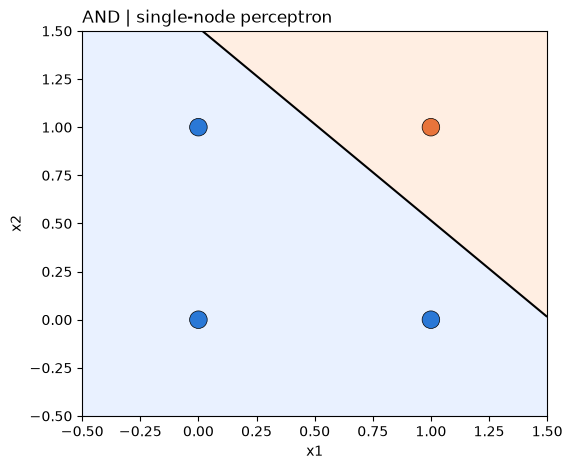

In [4]:
plot_decision_boundary(and_network, GATE_INPUTS, AND_TARGETS, title="AND | single-node perceptron");

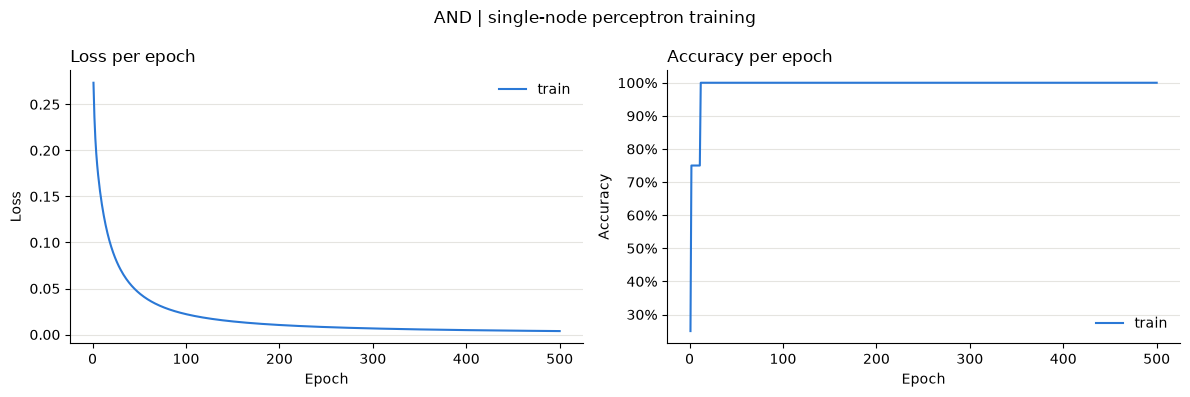

In [5]:
plot_history(and_trainer.history, title="AND | single-node perceptron training")

## XOR gate — where a single node fails

XOR is not linearly separable: no single straight line separates `{(0,1), (1,0)}`
from `{(0,0), (1,1)}`. A single node, no matter how it is trained, can only draw one
straight decision line, so it cannot solve XOR — this is the same architecture as
above, just trained on XOR data.

In [6]:
np.random.seed(0)

xor_network = build_perceptron()
xor_trainer = train_gate(xor_network, XOR_TARGETS)

epoch  100 | loss: 0.2995 | accuracy: 0.00%
epoch  200 | loss: 0.2996 | accuracy: 0.00%
epoch  300 | loss: 0.2996 | accuracy: 0.00%
epoch  400 | loss: 0.2996 | accuracy: 0.00%
epoch  500 | loss: 0.2996 | accuracy: 0.00%


In [7]:
report(xor_network, GATE_INPUTS, XOR_TARGETS)

layer 0 weights: [[-0.3797, -0.1898]]
layer 0 bias:    [0.1898]

inputs: [0.0000, 0.0000] | target: [0.0000] | prediction: [0.5473]
inputs: [0.0000, 1.0000] | target: [1.0000] | prediction: [0.5000]
inputs: [1.0000, 0.0000] | target: [1.0000] | prediction: [0.4527]
inputs: [1.0000, 1.0000] | target: [0.0000] | prediction: [0.4062]


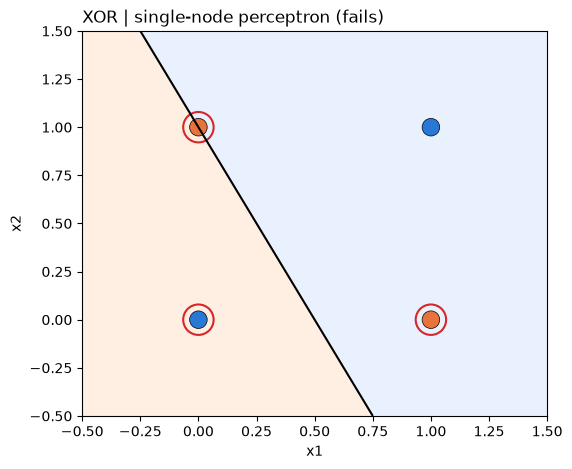

In [8]:
plot_decision_boundary(xor_network, GATE_INPUTS, XOR_TARGETS, title="XOR | single-node perceptron (fails)");

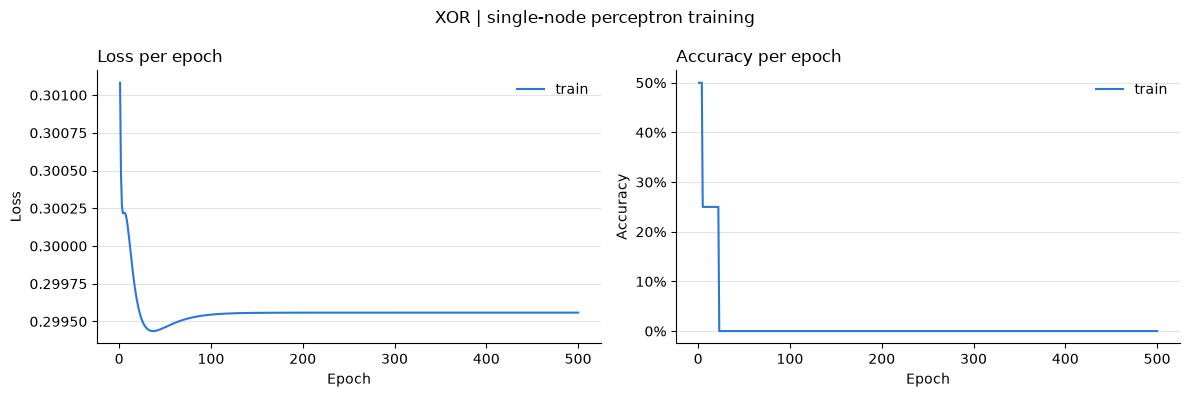

In [9]:
plot_history(xor_trainer.history, title="XOR | single-node perceptron training")

## Takeaway

On AND the loss falls steadily and every point ends on the correct side of the line. On XOR
gradient descent settles at the best a single line can do: every output is pulled toward 0.5,
the loss stays flat at about 0.30 from epoch 100 onward, and three of the four points (circled in
red) end on the wrong side. Solving XOR needs a second layer, which is the subject of Lab 2.